# **0. Descripción del proyecto 🚀**

## 🎯 Objetivo
Encontrar la mejor versión de cada modelo usando búsqueda de hiperparámetros, y comparar todos los resultados en una tabla final ordenada por métricas.

## 📊 Dataset
- Datos: Breast Cancer (Wisconsin)
- Filas: 569
- Columnas: 30
- variable objetivo (si existe)

## 🧠 Tipo de problema
Indicar si es:
- clasificación
- regresión
- clustering
- análisis exploratorio
- series temporales
- etc.

## 📏 Métricas
Definir cómo se evaluará el resultado:
- accuracy
- recall
- F1
- RMSE
- MAE
- etc.

## 🔍 Hipótesis iniciales
Ideas o sospechas previas sobre los datos o relaciones importantes.

## ⚙️ Flujo de trabajo
1. Carga de datos
2. Limpieza
3. EDA
4. Preprocesamiento / Feature Engineering
5. Modelado
6. Evaluación
7. Conclusiones


# **1. Librerías**

In [22]:
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

# Pipeline & GridSearch
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split

# Transformers
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report)

# Math & Dataframe
import numpy as np
import pandas as pd
import math

# Data
from sklearn.datasets import load_breast_cancer

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Time
import time


print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


# **2. Carga de datos**
- Cargar dataset
- Comprobar cantidad de filas y columnas
- Tipos de datos

In [23]:
breast_cancer = load_breast_cancer()

X = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
y = pd.Series(breast_cancer.target)

df = X.copy()
df['target'] = y

print('✅ Dataset cargado correctamente')

✅ Dataset cargado correctamente


In [24]:
# Tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

# **3. Inspección y limpieza de datos**

- Filas vacías o con valores NaN
- Columnas vacías o con valores NaN
- Datos faltantes
- Filas duplicadas
- Formatos incorrectos
- Valores imposibles

In [25]:
print('\n'+'#'*50+"\n")
print('\t- Datos:')
print('')
print(f'Filas: {df.shape[0]}')
print(f'Columnas: {df.shape[1]}')
print(f'-'*50)
print(f'Datos faltantes: {df.isna().sum().sum()}')
print(f'Datos duplicados: {df.duplicated().sum()}')
print(f'-'*50)

# Columnas y filas completamente vacías
print(f'Filas completamente vacías: {df.isnull().all(axis=1).sum()}')
vacias = df.isnull().mean()
print(f"Columnas completamente vacías: {(vacias == 1).sum()}")


# Columnas con al menos algún NaN
con_nan = df.isnull().any()
print(f"Columnas con algún NaN:        {con_nan.sum()}")

# Columnas con infinitos
con_inf = df.isin([np.inf, -np.inf]).any()
print(f"Columnas con infinitos:        {con_inf.sum()}")

print('\n'+'#'*50+"\n")


##################################################

	- Datos:

Filas: 569
Columnas: 31
--------------------------------------------------
Datos faltantes: 0
Datos duplicados: 0
--------------------------------------------------
Filas completamente vacías: 0
Columnas completamente vacías: 0
Columnas con algún NaN:        0
Columnas con infinitos:        0

##################################################



# **4. Análisis exploratorio**

- distribuciones
- correlaciones
- outliers
- relaciones entre variables
- hipótesis
- patrones

In [26]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')

In [27]:
# Separo las features por grupos lógicos para tener gráficas más claras
mean_features = [x for x in df.columns if x.startswith("mean")]
error_features = [x for x in df.columns if x.endswith("error")]
worst_features = [x for x in df.columns if x.startswith("worst")]


In [28]:
def graficar_grupo(grupo):
  cols = mean_features

  n_cols = 3
  n_rows = math.ceil(len(cols) / n_cols)

  fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))

  axes = axes.flatten()

  for i, col in enumerate(cols):
      sns.histplot(df[col], kde=True, ax=axes[i])
      axes[i].set_title(col)

  # eliminar gráficos vacíos
  for j in range(i + 1, len(axes)):
      fig.delaxes(axes[j])

  plt.tight_layout()
  plt.show()

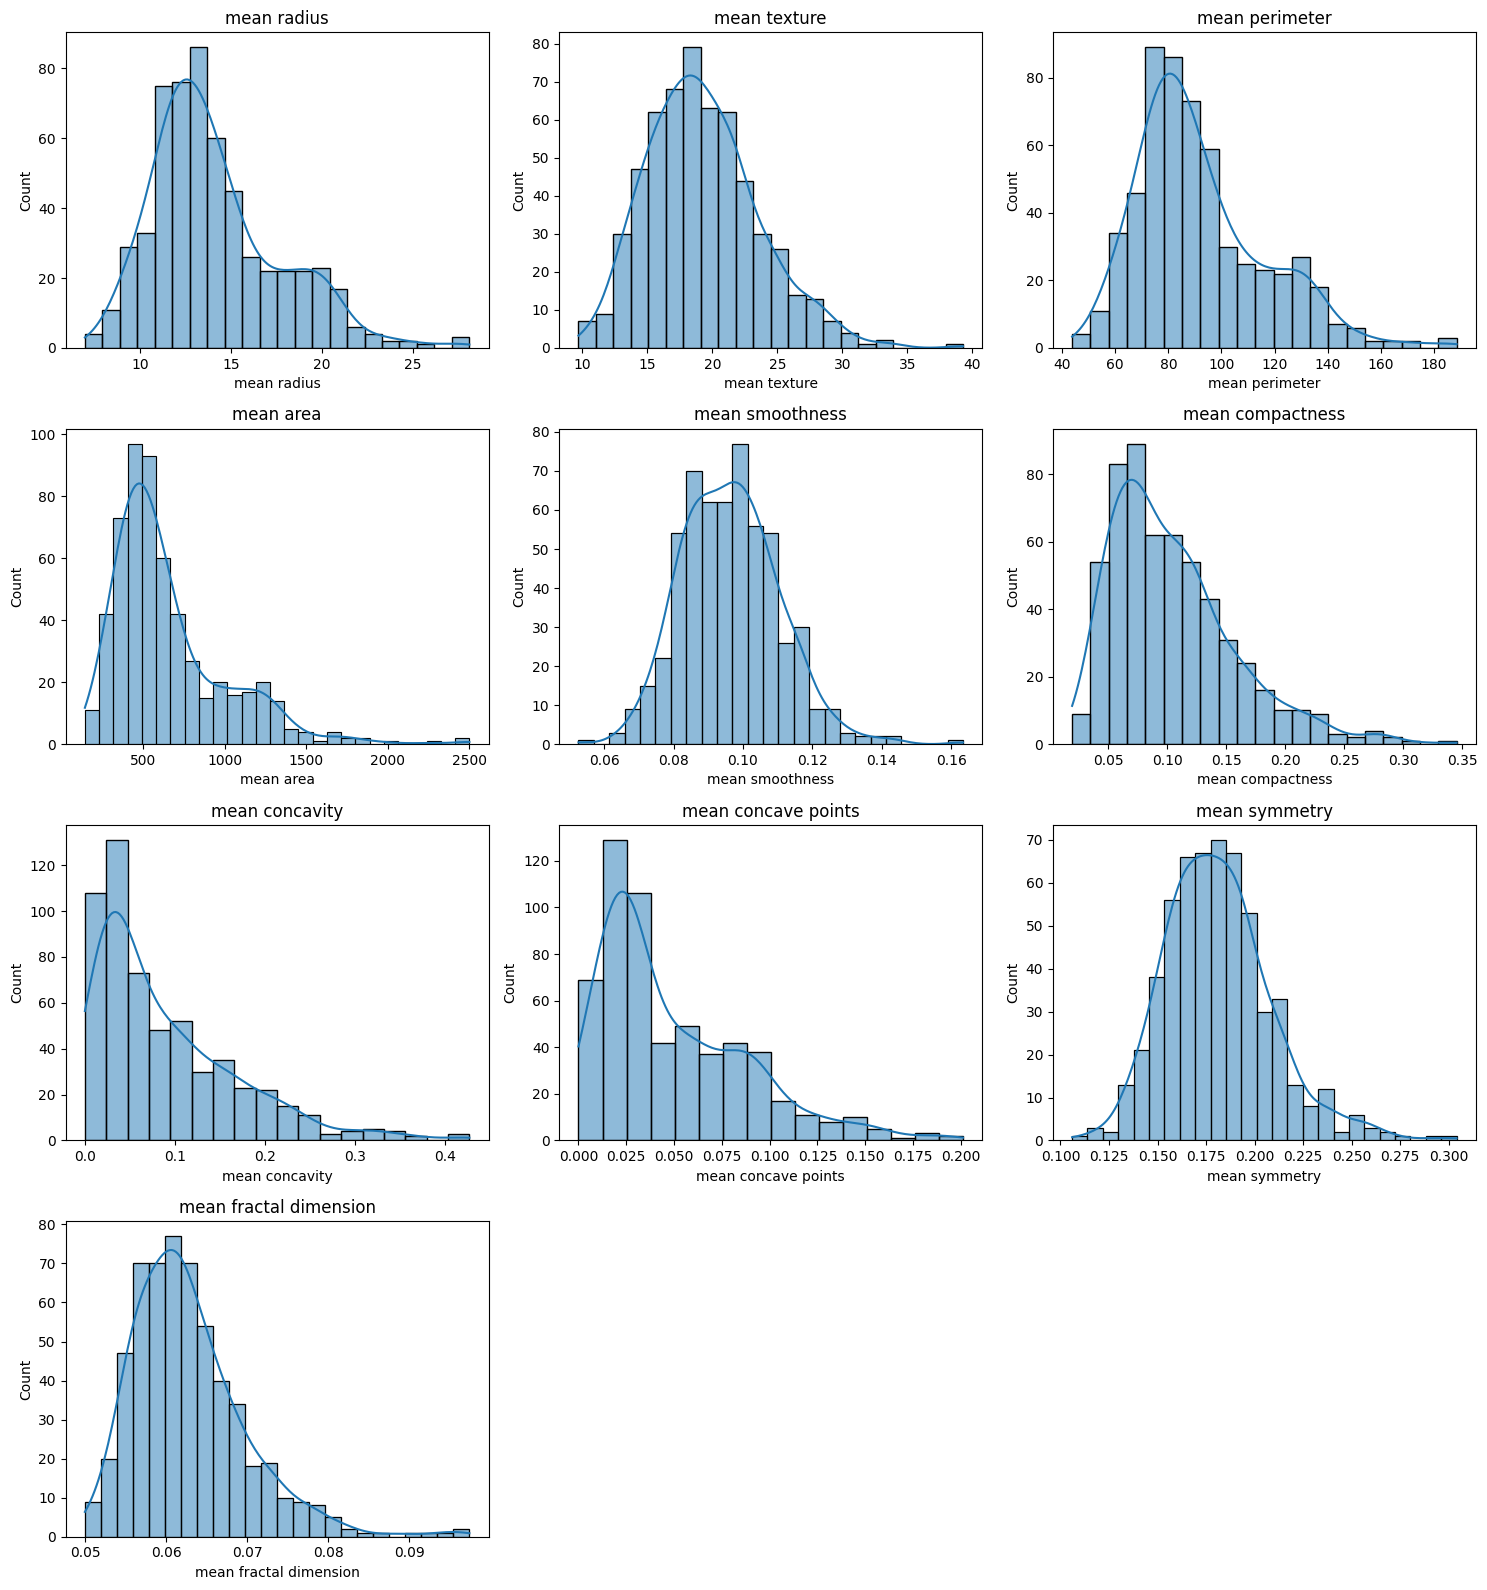

In [29]:
graficar_grupo(mean_features)

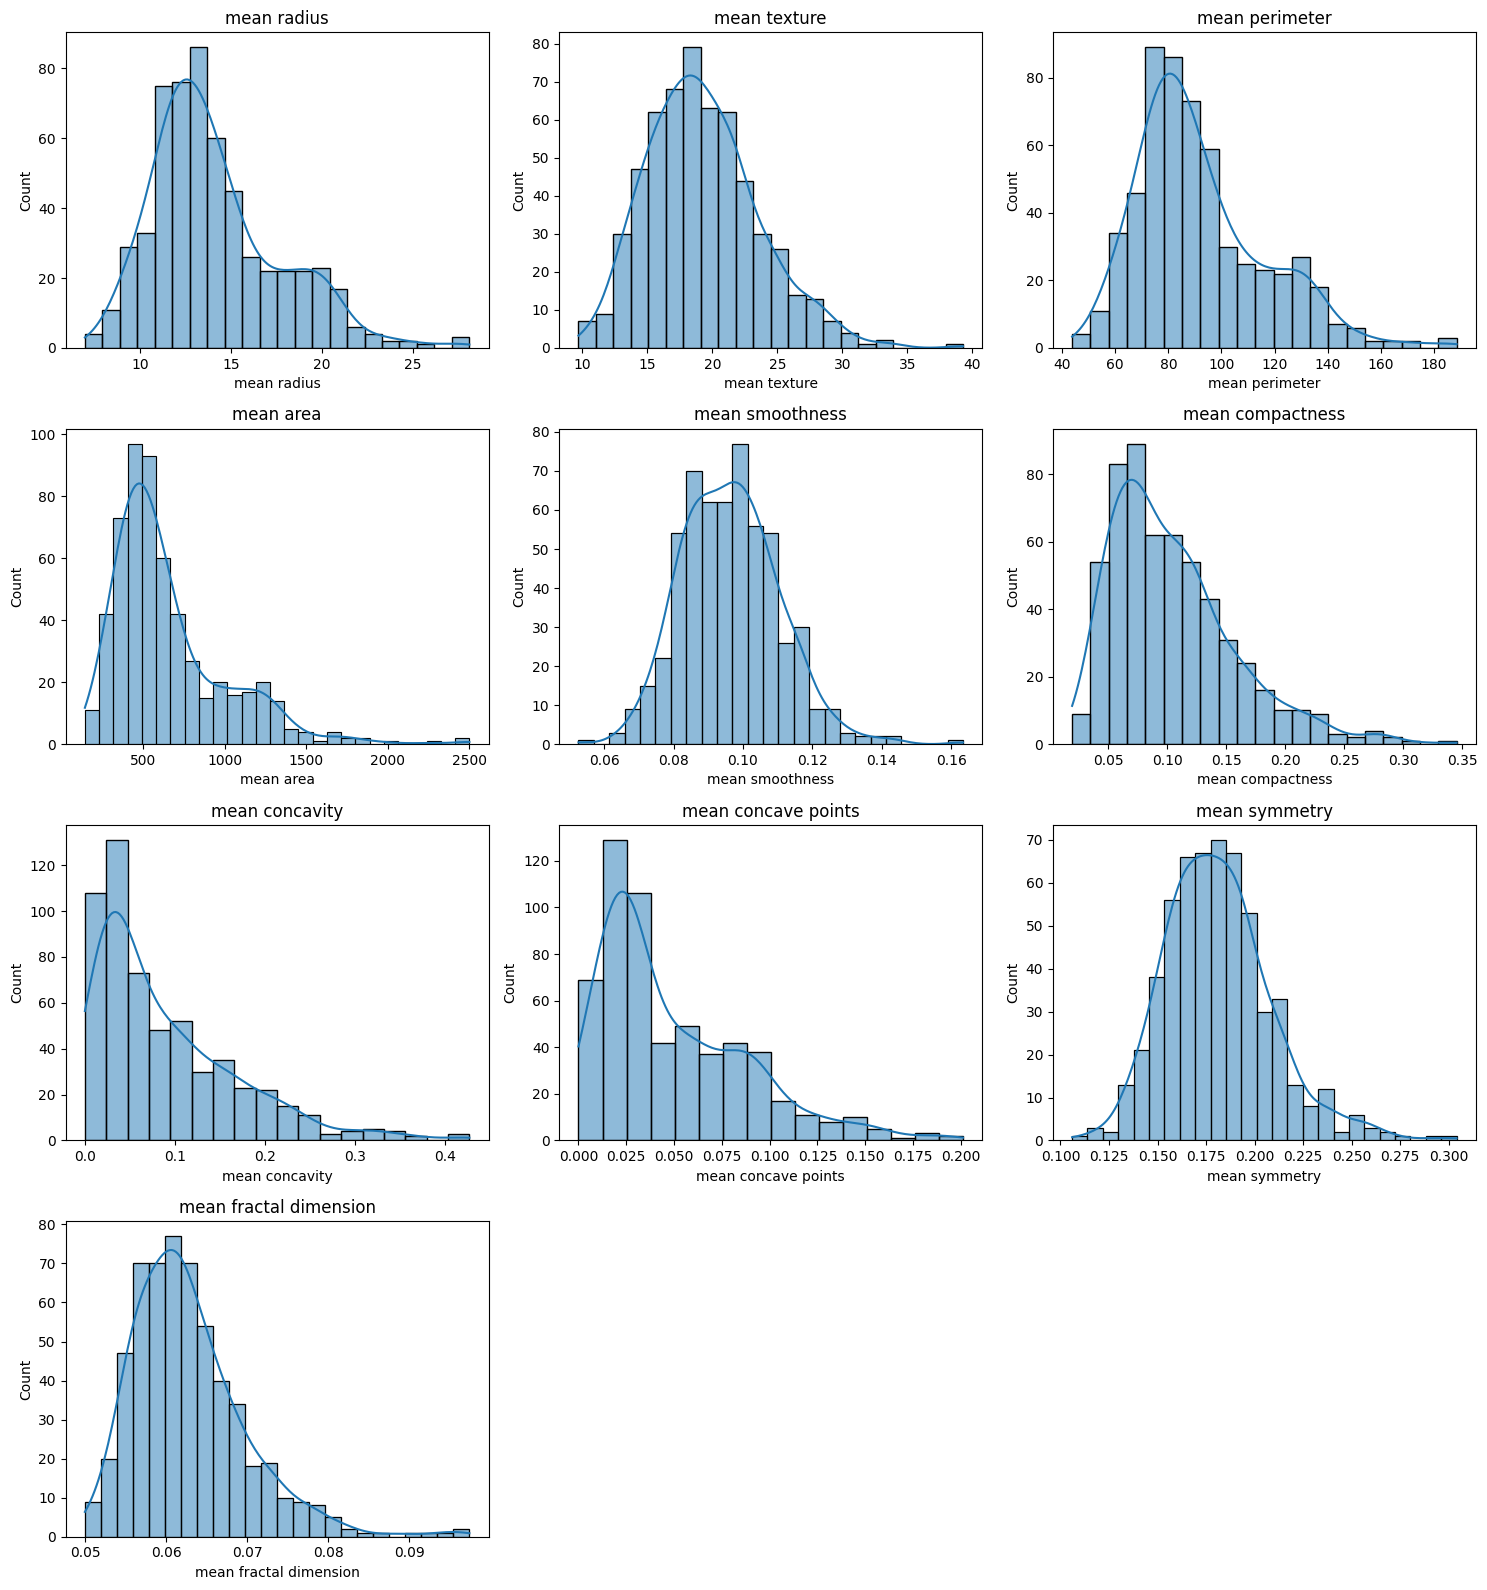

In [30]:
graficar_grupo(worst_features)

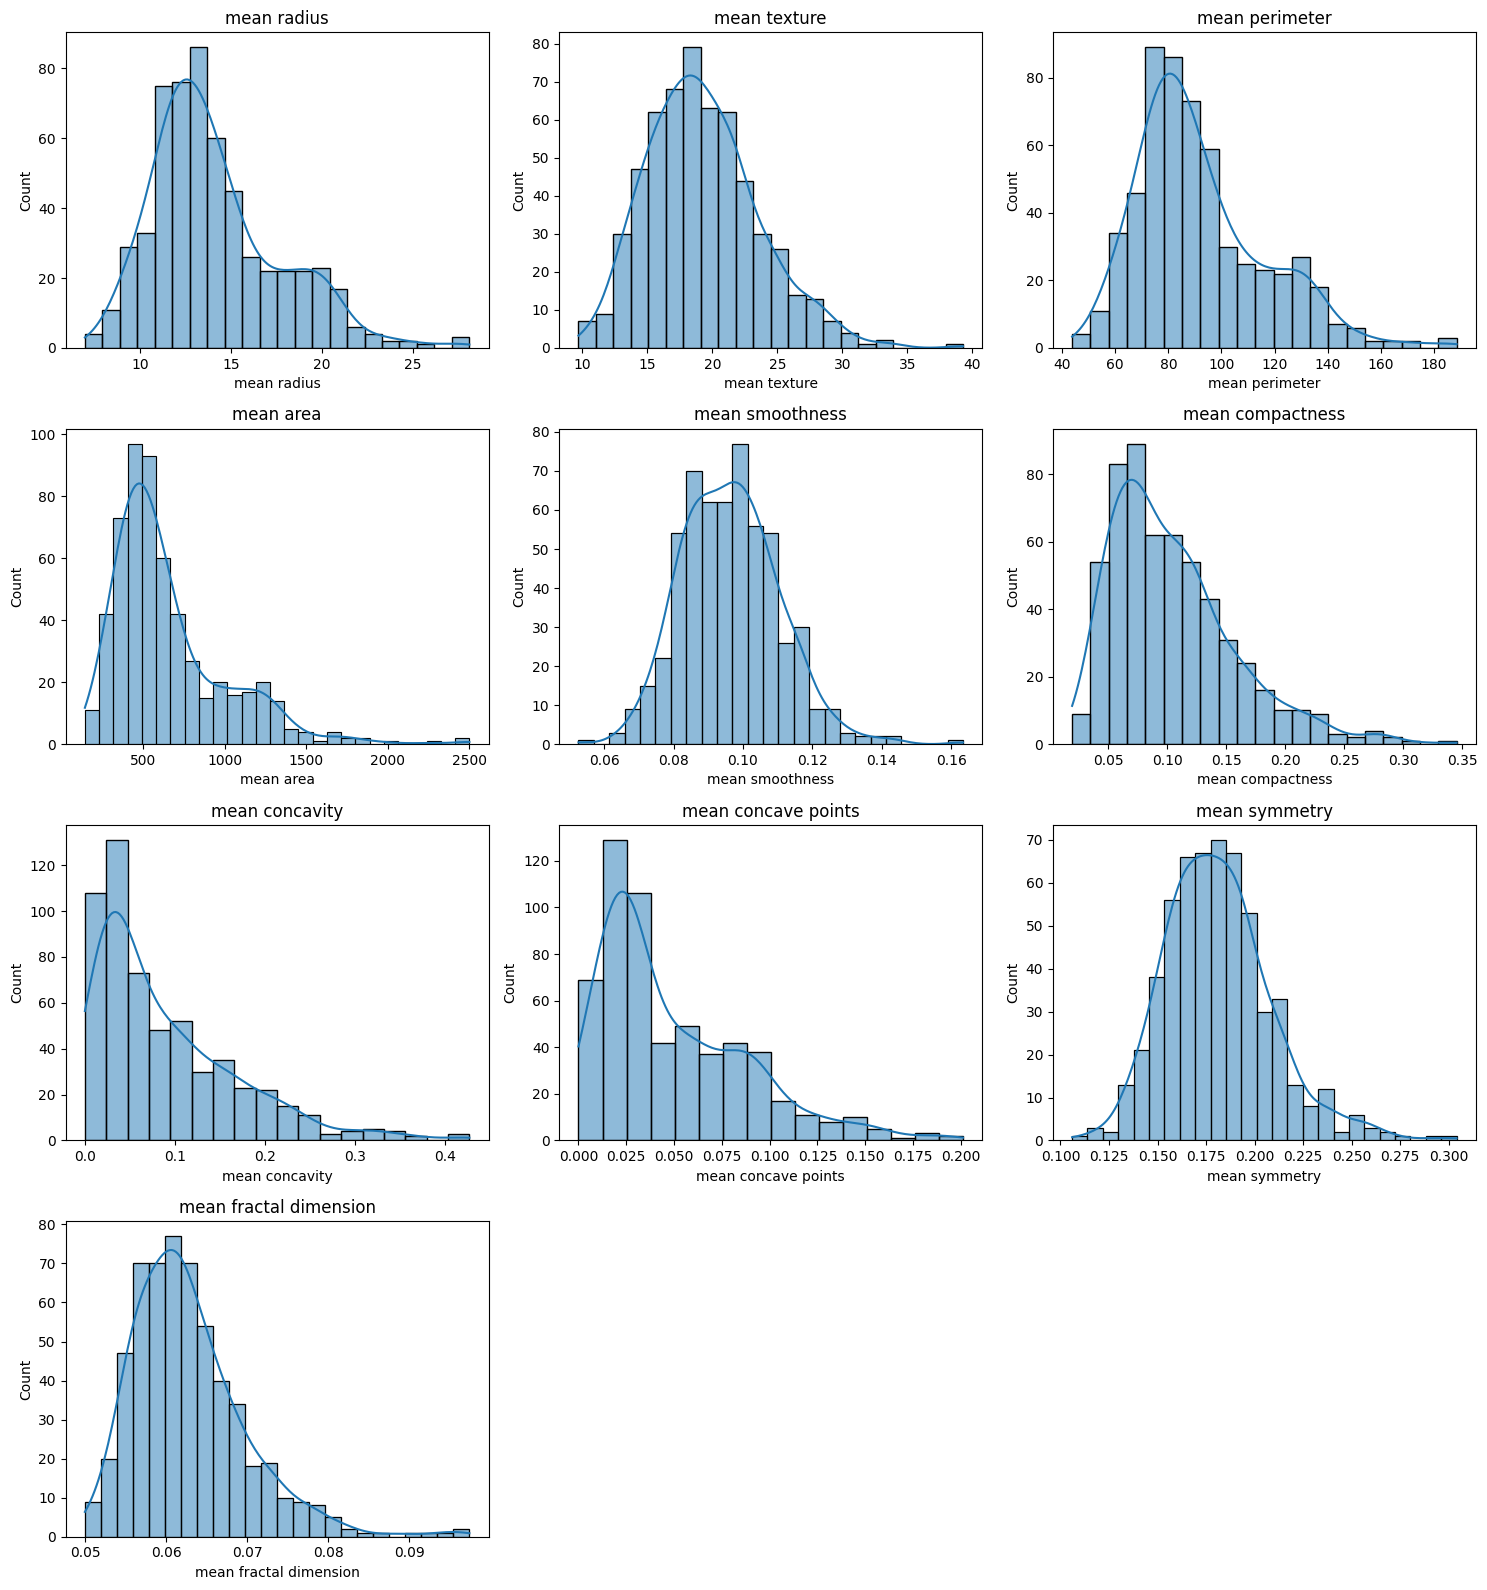

In [31]:
graficar_grupo(error_features)

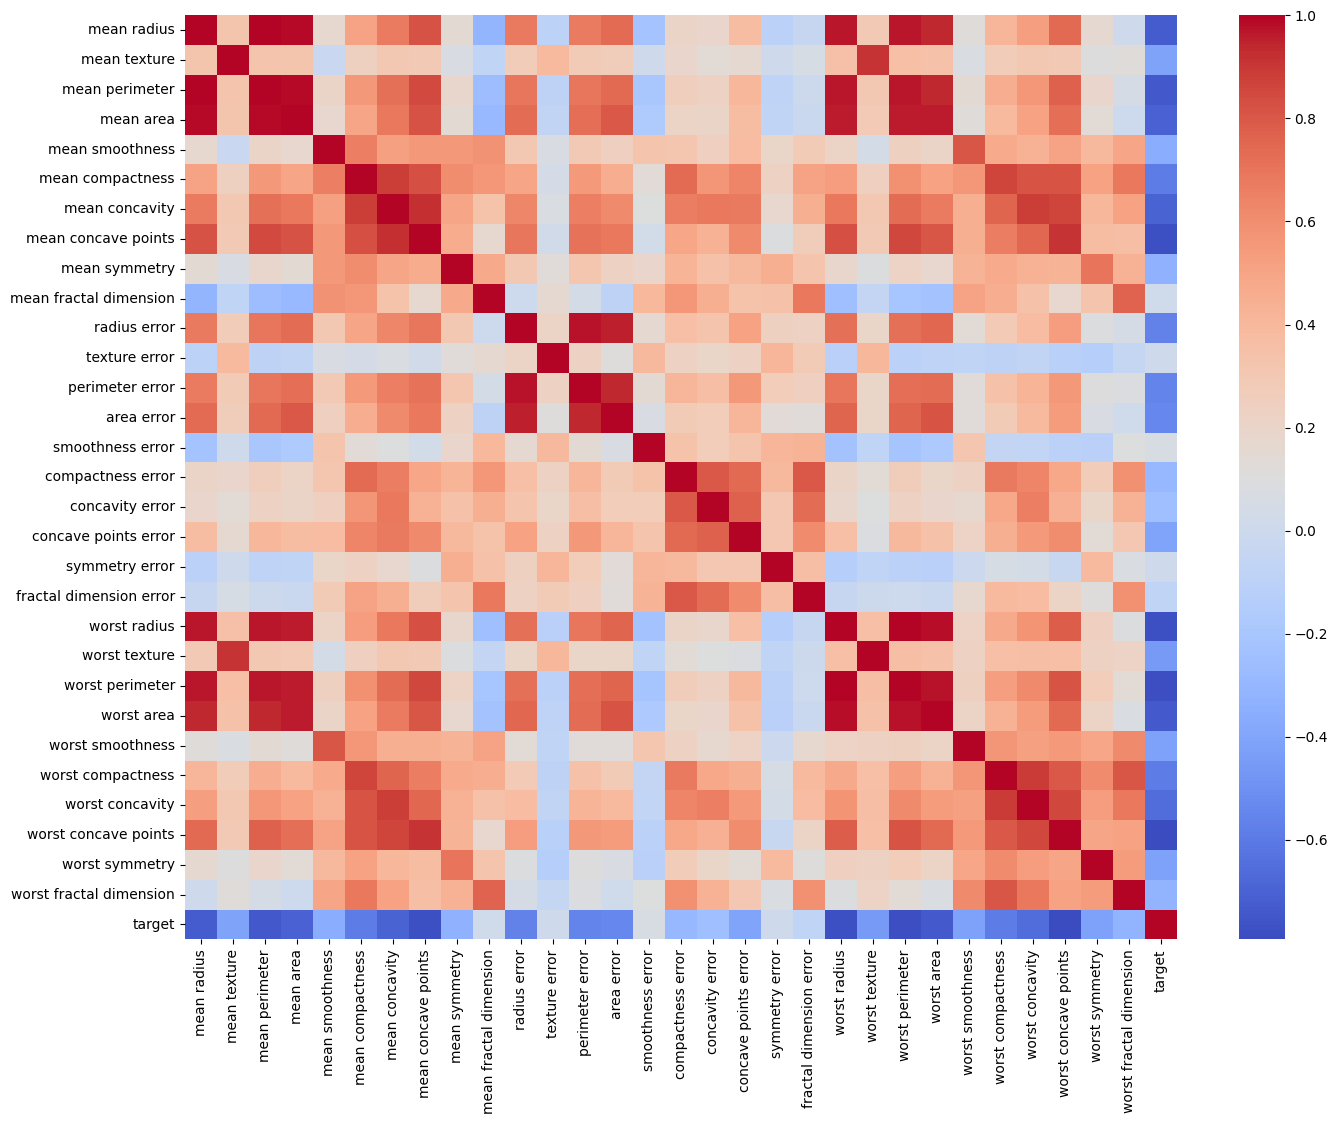

In [32]:
# Correlaciones entre las features para encontrar relaciones

corr = df.corr(numeric_only=True)

plt.figure(figsize=(16,12))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

## El mapa de correlaciones muestra una fuerte multicolinealidad entre muchas variables, especialmente dentro de grupos lógicos relacionados como radius, perimeter y area, así como entre las versiones mean y worst de varias features.

## Esto sugiere que múltiples variables contienen información muy similar o redundante. En consecuencia, algunas features podrían aportar poco valor adicional al modelo y generar redundancia estadística.

# **5. Feature engineering**
- Nuevas variables
- Agregaciones

In [33]:
## Voy a eliminar features con datos que no aportan información extra al modelo
X = X.drop(columns=['mean radius', 'mean perimeter', 'worst radius', 'worst perimeter'])


# **6. Preparación para modelado**
- Split train/test
- Pipelines
- Grid de modelos

In [34]:
# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras')
print(f'Test:  {X_test.shape[0]} muestras')

Train: 455 muestras
Test:  114 muestras


In [35]:
# Pipelines

# ── 1. SEPARAR COLUMNAS POR TIPO ────────────────────────────────────────────
num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numéricas : {num_cols}")
print(f"Categóricas: {cat_cols}")

# ── 2. PIPELINES DE TRANSFORMACIÓN ──────────────────────────────────────────

# Numéricas: imputar media → escalar
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',  StandardScaler()),
    # ('pca', PCA(n_components=None)),
])

num_transformer_pca = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',  StandardScaler()),
    ('pca', PCA(n_components=None)),
])


# Categóricas: imputar moda → one-hot encode
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ── 3. COLUMN TRANSFORMER ───────────────────────────────────────────────────

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

preprocessor_pca = ColumnTransformer([
    ('num', num_transformer_pca, num_cols),
    ('cat', cat_transformer, cat_cols)
])


print('✅ Preprocessor definido')

Numéricas : ['mean texture', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst texture', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']
Categóricas: []
✅ Preprocessor definido


In [36]:
# Grid de modelos

# --- Logistic Regression ---
pipe_lr = Pipeline([
    ('preprocessor', preprocessor_pca),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])
grid_lr = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['lbfgs', 'liblinear'],
    'model__penalty': ['l2'],
    'preprocessor__num__pca__n_components': [0.90, 0.92, 0.95, 0.97, 0.99]

}

# --- KNN ---
pipe_knn = Pipeline([
    ('preprocessor', preprocessor_pca),
    ('model', KNeighborsClassifier())
])
grid_knn = {
    'model__n_neighbors': [3, 5, 7, 9, 11, 15],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan'],
    'preprocessor__num__pca__n_components': [0.90, 0.92, 0.95, 0.97, 0.99]

}

# --- Decision Tree ---
pipe_dt = Pipeline([
    ('preprocessor', preprocessor),  # no afecta DT, pero mantiene consistencia
    ('model', DecisionTreeClassifier(random_state=42))
])
grid_dt = {
    'model__max_depth': [3, 5, 7, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__criterion': ['gini', 'entropy'],
    # 'preprocessor__num__pca__n_components': [None]
}

# --- Random Forest ---
pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])
grid_rf = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [5, 10, None],
    'model__min_samples_split': [2, 5],
    'model__max_features': ['sqrt', 'log2'],
    # 'preprocessor__num__pca__n_components': [None]
}

# --- SVM ---
pipe_svm = Pipeline([
    ('preprocessor', preprocessor_pca),
    ('model', SVC(random_state=42))
])
grid_svm = {
    'model__C': [0.1, 1, 10, 100],
    'model__kernel': ['rbf', 'linear', 'poly'],
    'model__gamma': ['scale', 'auto'],
    'preprocessor__num__pca__n_components': [0.90, 0.92, 0.95, 0.97, 0.99]

}

# --- Gradient Boosting ---
pipe_gb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(random_state=42))
])
grid_gb = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 7],
    'model__subsample': [0.8, 1.0],
    # 'preprocessor__num__pca__n_components': [None]
}

# --- XGBoost ---
pipe_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(random_state=42, eval_metric='logloss'))
])
grid_xgb = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 7],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
    # 'preprocessor__num__pca__n_components': [None]
}

# Agrupar todo
modelos = {
    'Logistic Regression': (pipe_lr, grid_lr),
    'KNN':                 (pipe_knn, grid_knn),
    'Decision Tree':       (pipe_dt, grid_dt),
    'Random Forest':       (pipe_rf, grid_rf),
    'SVM':                 (pipe_svm, grid_svm),
    'Gradient Boosting':   (pipe_gb, grid_gb),
    'XGBoost':             (pipe_xgb, grid_xgb)
}

print('✅ Pipelines y grids definidos')

✅ Pipelines y grids definidos


# **7. Modelado**
- Grid search
- Métricas

In [37]:
resultados = []
mejores_modelos = {}

for nombre, (pipeline, param_grid) in modelos.items():
    print(f'🔍 Buscando mejores parámetros para: {nombre}...')

    gs = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=0
    )

    t_inicio = time.perf_counter()
    gs.fit(X_train, y_train)
    t_fin = time.perf_counter()
    duracion = t_fin - t_inicio

    # Evaluar sobre test set con el mejor modelo encontrado
    y_pred = gs.best_estimator_.predict(X_test)

    # Guardar mejores params y modelo
    mejores_modelos[nombre] = gs.best_estimator_

    resultados.append({
        'Modelo':            nombre,
        'Accuracy':          round(accuracy_score(y_test, y_pred), 4),
        'Precision':         round(precision_score(y_test, y_pred), 4),
        'Recall':            round(recall_score(y_test, y_pred), 4),
        'F1':                round(f1_score(y_test, y_pred), 4),
        'CV F1 (mean)':      round(gs.best_score_, 4),
        # 'PCA n_components':  gs.best_params_.get('preprocessor__num__pca__n_components', 'N/A'),
        'Mejores Params':    str(gs.best_params_),
        'Matriz':            confusion_matrix(y_test, y_pred)
    })

    print(f'  ✅ Mejor F1 CV: {gs.best_score_:.4f} | F1 Test: {f1_score(y_test, y_pred):.4f}')
    print(f'  📌 Params: {gs.best_params_}')
    print(f'  ⏱️ Tiempo: {duracion:.2f}s\n')

print('🎉 GridSearch completado para todos los modelos!')

🔍 Buscando mejores parámetros para: Logistic Regression...
  ✅ Mejor F1 CV: 0.9862 | F1 Test: 0.9793
  📌 Params: {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs', 'preprocessor__num__pca__n_components': 0.97}
  ⏱️ Tiempo: 6.18s

🔍 Buscando mejores parámetros para: KNN...
  ✅ Mejor F1 CV: 0.9711 | F1 Test: 0.9722
  📌 Params: {'model__metric': 'euclidean', 'model__n_neighbors': 5, 'model__weights': 'distance', 'preprocessor__num__pca__n_components': 0.9}
  ⏱️ Tiempo: 10.82s

🔍 Buscando mejores parámetros para: Decision Tree...
  ✅ Mejor F1 CV: 0.9584 | F1 Test: 0.9645
  📌 Params: {'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_samples_split': 10}
  ⏱️ Tiempo: 2.72s

🔍 Buscando mejores parámetros para: Random Forest...
  ✅ Mejor F1 CV: 0.9701 | F1 Test: 0.9793
  📌 Params: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_split': 2, 'model__n_estimators': 200}
  ⏱️ Tiempo: 45.96s

🔍 Buscando mejores parámetros para: SVM...
  ✅ 

In [38]:
# Crear DataFrame sin la columna de matrices (para mostrar)
df_res = pd.DataFrame(resultados).drop(columns=['Matriz', 'Mejores Params'])
df_res = df_res.sort_values('F1', ascending=False).reset_index(drop=True)
df_res.index = df_res.index + 1  # ranking desde 1

# Agregar medalla al mejor
df_res.insert(0, 'Rank', ['🥇', '🥈', '🥉', '4️⃣', '5️⃣','6️⃣','7️⃣'][:len(df_res)])

print('📊 TABLA FINAL — Mejores modelos (ordenados por F1)\n')
df_res

📊 TABLA FINAL — Mejores modelos (ordenados por F1)



,Rank,Modelo,Accuracy,Precision,Recall,F1,CV F1 (mean)
1,🥇,SVM,0.9825,0.9730,1.0000,0.9863,0.9860
2,🥈,XGBoost,0.9737,0.9600,1.0000,0.9796,0.9845
3,🥉,Logistic Regression,0.9737,0.9726,0.9861,0.9793,0.9862
4,4️⃣,Random Forest,0.9737,0.9726,0.9861,0.9793,0.9701
5,5️⃣,Gradient Boosting,0.9737,0.9726,0.9861,0.9793,0.9826
6,6️⃣,KNN,0.9649,0.9722,0.9722,0.9722,0.9711
7,7️⃣,Decision Tree,0.9561,0.9855,0.9444,0.9645,0.9584


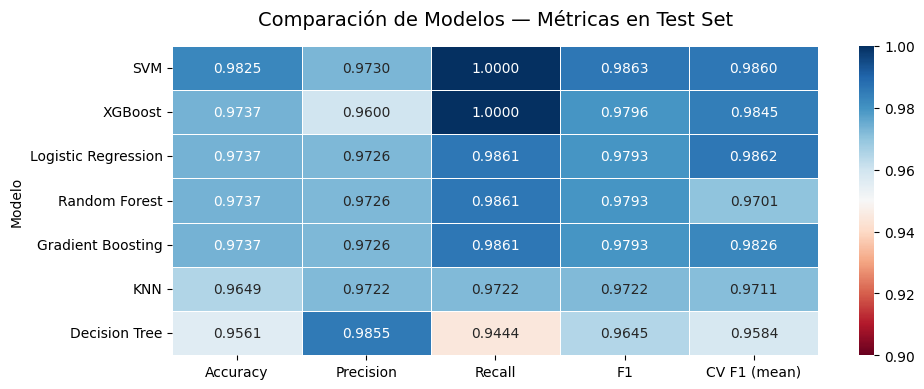

In [39]:
metricas = ['Accuracy', 'Precision', 'Recall', 'F1', 'CV F1 (mean)']
df_heat = df_res.set_index('Modelo')[metricas]

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    df_heat,
    annot=True,
    fmt='.4f',
    cmap='RdBu',
    linewidths=0.5,
    linecolor='white',
    vmin=0.9,
    vmax=1.0,
    ax=ax
)
ax.set_title('Comparación de Modelos — Métricas en Test Set', fontsize=14, pad=15)
ax.set_xlabel('')
plt.tight_layout()
plt.show()

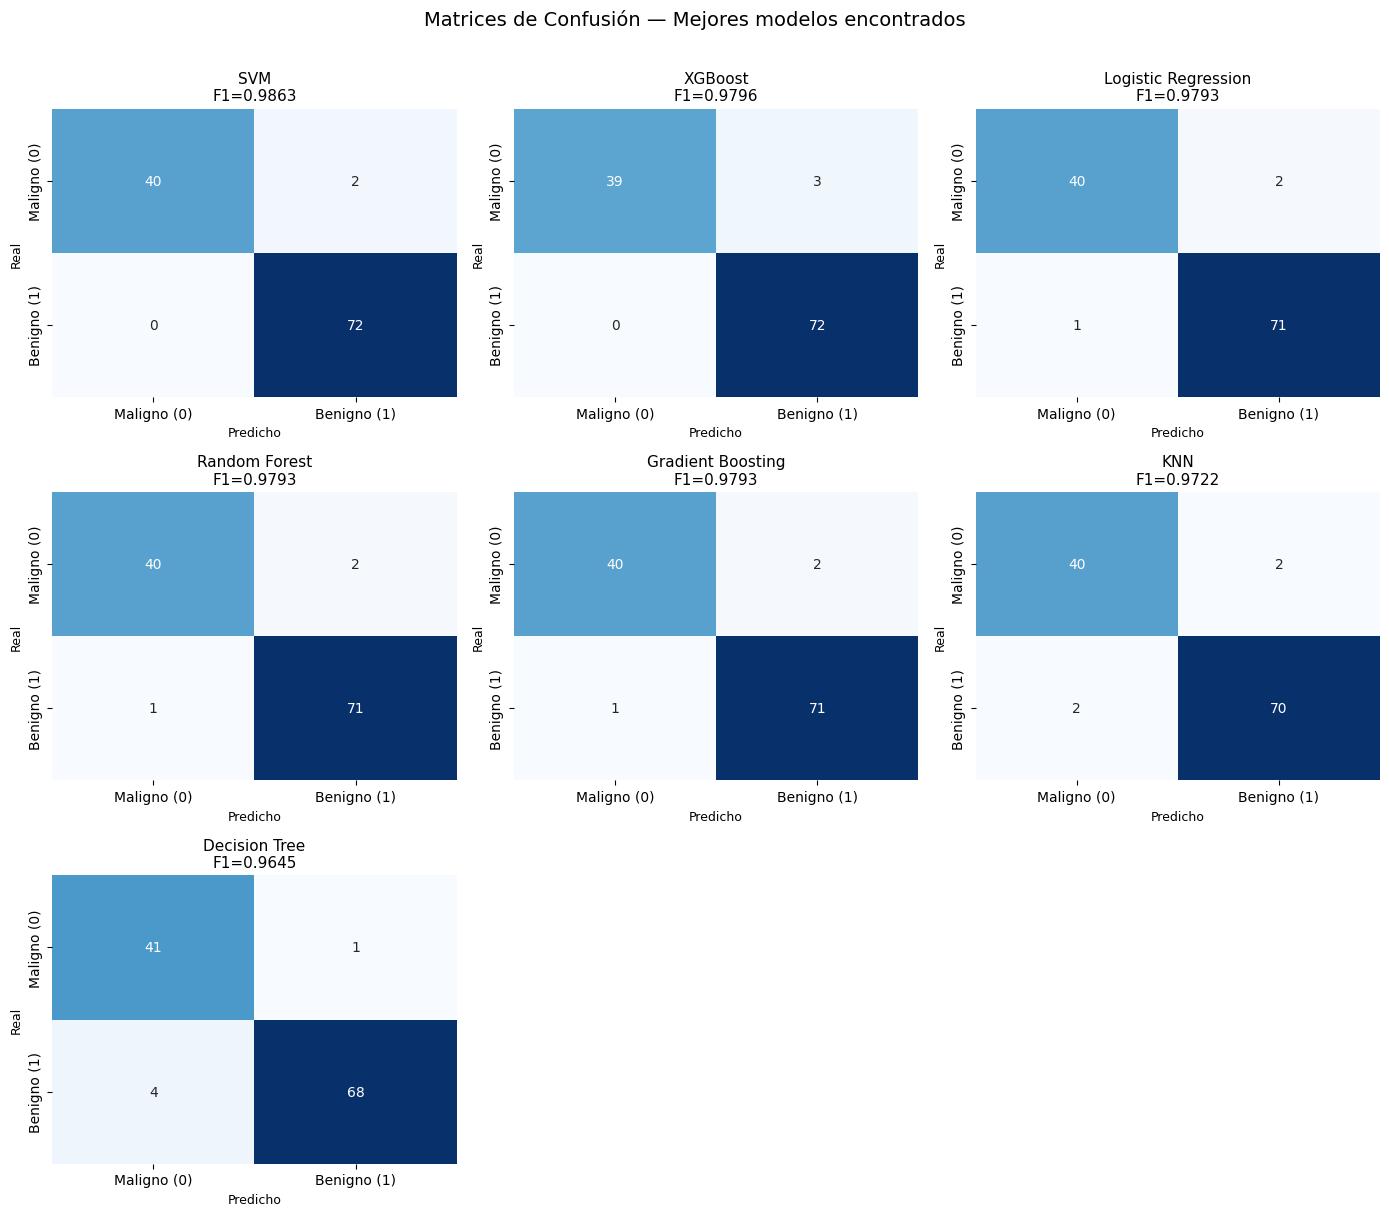

In [40]:
n = len(resultados)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 4))
axes = axes.flatten()

# Ordenar por F1 para que el ranking coincida con la tabla
resultados_ordenados = sorted(resultados, key=lambda x: x['F1'], reverse=True)

for i, res in enumerate(resultados_ordenados):
    ax = axes[i]
    cm = res['Matriz']
    nombre = res['Modelo']
    f1 = res['F1']

    labels = ['Maligno (0)', 'Benigno (1)']
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        cbar=False,
        xticklabels=labels,
        yticklabels=labels
    )
    # rank = ['🥇','🥈','🥉','4️⃣','5️⃣'][i]
    ax.set_title(f'{nombre}\nF1={f1:.4f}', fontsize=11)
    ax.set_xlabel('Predicho', fontsize=9)
    ax.set_ylabel('Real', fontsize=9)

# Ocultar ejes sobrantes
for j in range(len(resultados), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Matrices de Confusión — Mejores modelos encontrados', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [41]:
mejor_nombre = df_res.iloc[0]['Modelo']
mejor_modelo  = mejores_modelos[mejor_nombre]

y_pred_best = mejor_modelo.predict(X_test)

print(f'🏆 MEJOR MODELO: {mejor_nombre}')
print('=' * 50)
print(f'Parámetros usados: {mejor_modelo.named_steps["model"].get_params()}')
print()
print('📋 Classification Report:')
print(classification_report(
    y_test, y_pred_best,
    target_names=['Maligno (0)', 'Benigno (1)']
))

🏆 MEJOR MODELO: SVM
Parámetros usados: {'C': 1, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}

📋 Classification Report:
              precision    recall  f1-score   support

 Maligno (0)       1.00      0.95      0.98        42
 Benigno (1)       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [42]:
df_params = pd.DataFrame(resultados).drop(columns=['Matriz'])
df_params = df_params.sort_values('F1', ascending=False).reset_index(drop=True)
df_params.index = df_params.index + 1

pd.set_option('display.max_colwidth', None)
df_params[['Modelo', 'F1', 'Accuracy', 'CV F1 (mean)', 'Mejores Params']]

,Modelo,F1,Accuracy,CV F1 (mean),Mejores Params
1,SVM,0.9863,0.9825,0.9860,"{'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf', 'preprocessor__num__pca__n_components': 0.95}"
2,XGBoost,0.9796,0.9737,0.9845,"{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}"
3,Logistic Regression,0.9793,0.9737,0.9862,"{'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs', 'preprocessor__num__pca__n_components': 0.97}"
4,Random Forest,0.9793,0.9737,0.9701,"{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_split': 2, 'model__n_estimators': 200}"
5,Gradient Boosting,0.9793,0.9737,0.9826,"{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}"
6,KNN,0.9722,0.9649,0.9711,"{'model__metric': 'euclidean', 'model__n_neighbors': 5, 'model__weights': 'distance', 'preprocessor__num__pca__n_components': 0.9}"
7,Decision Tree,0.9645,0.9561,0.9584,"{'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_samples_split': 10}"


# **8. Evaluación**
- Resultados
- Análisis del error

# **9. Conclusión**


# Los resultados muestran cómo técnicas de preprocessing, selección de features y tuning de hiperparámetros pueden impactar significativamente en la calidad final del modelo.
# Este proyecto demuestra la importancia de combinar análisis exploratorio, ingeniería de variables y validación rigurosa para construir modelos confiables en contextos sensibles como el diagnóstico médico.

# **Precision vs Recall**

## En problemas médicos, el Recall adquiere especial importancia ya que minimizar falsos negativos es crítico.
# Detectar incorrectamente un tumor maligno como benigno puede tener consecuencias graves, por lo que se priorizó un equilibrio fuerte entre Recall y Precision usando F1-score.

## Por esta razón los modelos ganadores no solo lo son en función de su métrica F1 más elevada, sino porque además presentan un Recall de 1, lo cual sería simplemente perfecto en el ámbito de la medicina, reduciendo a 0 los falsos negativos.